In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
#from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import VarianceThreshold
#from sklearn.metrics import roc_curve, auc
from sklearn import svm
from sklearn.svm import SVC
from sklearn.svm import LinearSVC 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
#from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn import naive_bayes
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, roc_curve, auc
warnings.filterwarnings('ignore')
from sklearn.metrics import ConfusionMatrixDisplay

# INTERSECTION

In [2]:
dat = pd.read_csv('intersection.csv')
dat

,Time,VehicleId,Pos_x,Pos_y,Type,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Slope
0,0.0,0,0.69,1172.48,DEFAULTVEHTYPE,12.59,3.626090e+10,-1,-1.00,-1.00,6.97,0
1,0.1,0,0.70,1172.46,DEFAULTVEHTYPE,0.25,3.626090e+10,-1,-1.00,-1.00,4.91,0
2,0.2,0,0.72,1172.41,DEFAULTVEHTYPE,0.49,3.626090e+10,-1,-1.00,-1.00,5.49,0
3,0.3,0,0.75,1172.35,DEFAULTVEHTYPE,0.73,3.626090e+10,-1,-1.00,-1.00,5.32,0
4,0.4,0,0.79,1172.26,DEFAULTVEHTYPE,0.95,3.626090e+10,-1,-1.00,-1.00,4.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,DEFAULTVEHTYPE,13.82,3.362609e+11,-1,-1.00,-1.00,5.30,0
57467,199.9,52,1003.47,55.91,DEFAULTVEHTYPE,14.46,3.626090e+10,45,14.49,1.24,5.26,0
57468,199.9,45,1018.61,37.71,DEFAULTVEHTYPE,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61,0
57469,200.0,47,816.79,277.58,DEFAULTVEHTYPE,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85,0


In [3]:
dt=dat.drop(labels='Type', axis=1)
dt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Slope
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97,0
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91,0
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49,0
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32,0
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99,0
...,...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30,0
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26,0
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61,0
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85,0


In [4]:
dataset=dt.drop(labels='Slope', axis=1)
dataset

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99
...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85


In [5]:
my_list = ['LeaderGap', 'LeaderSpeed']

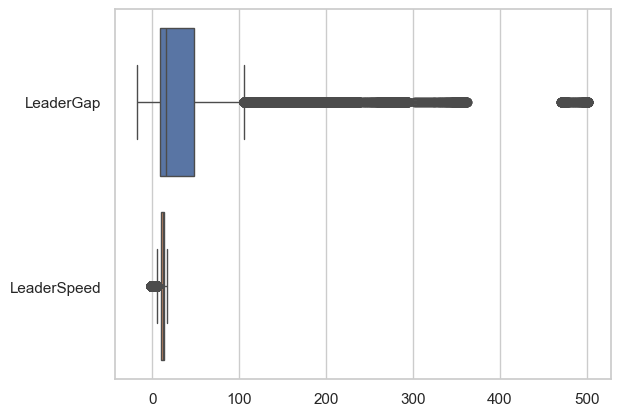

In [6]:
sns.set(style='whitegrid')
ax = sns.boxplot(data = dataset[my_list], orient = 'h')

In [7]:
percentile25 = dataset['LeaderGap'].quantile(0.25)
percentile75 = dataset['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  47.54
25th quartile:  9.25


In [8]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)

IQR:  38.29


In [9]:
lower_limit = dataset['LeaderGap'].quantile(0.25)-1.5*iqr
lower_limit

-48.185

In [10]:
upper_limit = dataset['LeaderGap'].quantile(0.75)+1.5*iqr
upper_limit

104.975

In [11]:
dataset[(dataset.LeaderGap > upper_limit) | (dataset.LeaderGap < lower_limit)]

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
757,13.2,12,463.01,723.87,2.45,3.627040e+09,3,8.11,156.89,6.44
758,13.2,13,497.62,629.01,0.26,3.362609e+11,3,8.11,105.36,-7.56
770,13.3,12,462.84,724.08,2.64,3.627040e+09,3,8.34,157.46,-4.96
771,13.3,13,497.59,629.05,0.51,3.362609e+11,3,8.34,106.14,-7.54
783,13.4,12,462.67,724.30,2.84,3.627040e+09,3,8.58,158.04,5.35
...,...,...,...,...,...,...,...,...,...,...
56194,182.8,39,76.06,1064.30,12.46,3.362609e+11,34,13.78,126.01,-7.10
56205,182.9,39,75.24,1065.23,12.44,3.362609e+11,34,13.70,126.14,5.18
56216,183.0,39,74.41,1066.17,12.48,3.362609e+11,34,13.79,126.27,5.42
56227,183.1,39,73.59,1067.11,12.50,3.362609e+11,34,13.78,126.40,-5.22


In [12]:
new_dt = dataset[~((dataset.LeaderGap < lower_limit)|(dataset.LeaderGap > upper_limit))]
new_dt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99
...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85


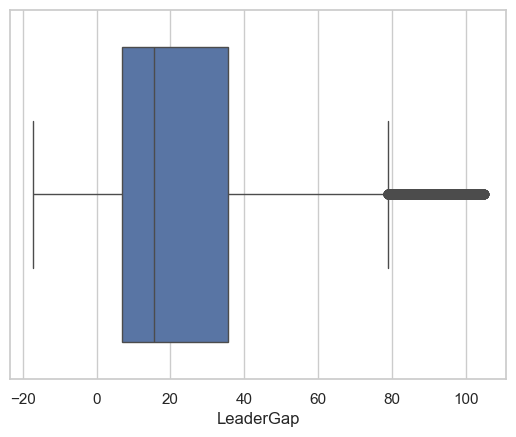

In [13]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = new_dt.LeaderGap, orient = 'h')

In [14]:
percentile25 = new_dt['LeaderGap'].quantile(0.25)
percentile75 = new_dt['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  35.68
25th quartile:  6.91


In [15]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Lower limit
lower_limit = new_dt['LeaderGap'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)
#Upper limit
upper_limit = new_dt['LeaderGap'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)

IQR:  28.77
Lower_limit:  -36.245000000000005
Upper_limit:  78.83500000000001


In [16]:
new_dt[(new_dt.LeaderGap > upper_limit) | (new_dt.LeaderGap < lower_limit)]

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
641,12.2,12,463.96,722.68,0.25,3.627040e+09,6,12.34,79.80,-6.48
653,12.3,12,463.93,722.72,0.51,3.627040e+09,6,12.47,80.99,4.60
665,12.4,12,463.88,722.78,0.76,3.627040e+09,6,12.62,82.18,-6.47
677,12.5,12,463.82,722.86,1.01,3.627040e+09,6,12.87,83.37,-7.53
689,12.6,12,463.74,722.95,1.24,3.627040e+09,6,13.11,84.55,5.32
...,...,...,...,...,...,...,...,...,...,...
54106,168.7,23,54.90,1089.04,12.25,3.362609e+11,21,14.02,92.68,5.48
54123,168.8,23,54.11,1089.98,12.31,3.362609e+11,21,13.99,92.85,5.52
54140,168.9,23,53.32,1090.92,12.31,3.362609e+11,21,13.96,93.02,4.69
54157,169.0,23,52.56,1091.89,12.23,3.362609e+11,21,14.01,93.20,-7.78


In [17]:
nw_dt = new_dt[~((new_dt.LeaderGap < lower_limit) | (new_dt.LeaderGap > upper_limit))]
nw_dt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99
...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85


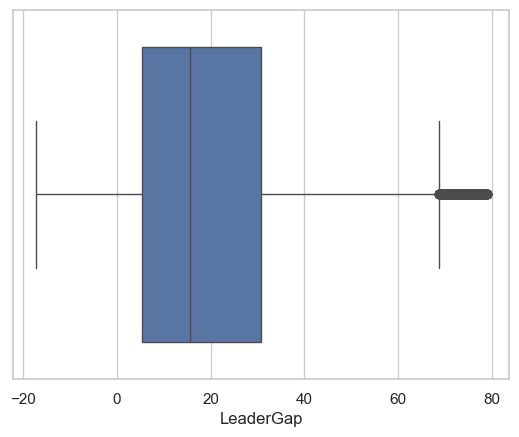

In [18]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = nw_dt.LeaderGap, orient = 'h')

In [19]:
percentile25 = nw_dt['LeaderGap'].quantile(0.25)
percentile75 = nw_dt['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Upper limit
upper_limit = nw_dt['LeaderGap'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)
#Lower limit
lower_limit = nw_dt['LeaderGap'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)

75th quartile:  30.78
25th quartile:  5.4775
IQR:  25.302500000000002
Upper_limit:  68.73375
Lower_limit:  -32.47625


In [20]:
dt = nw_dt[~((nw_dt.LeaderGap < lower_limit)|(nw_dt.LeaderGap > upper_limit))]
dt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99
...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85


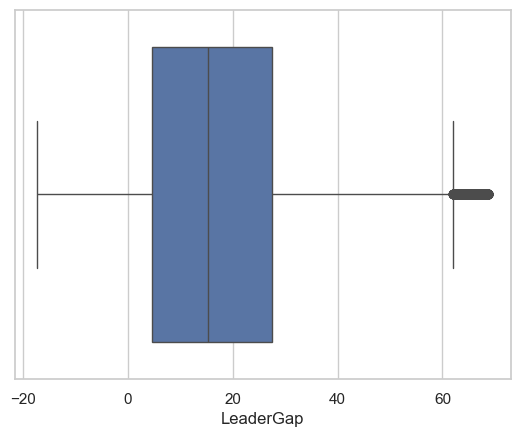

In [21]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = dt.LeaderGap, orient = 'h')

In [22]:
percentile25 = dt['LeaderGap'].quantile(0.25)
percentile75 = dt['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Upper limit
upper_limit = dt['LeaderGap'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)
#Lower limit
lower_limit = dt['LeaderGap'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)

75th quartile:  27.575
25th quartile:  4.57
IQR:  23.005
Upper_limit:  62.082499999999996
Lower_limit:  -29.9375


In [23]:
data = dt[~((dt.LeaderGap < lower_limit)|(dt.LeaderGap > upper_limit))]
data

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99
...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85


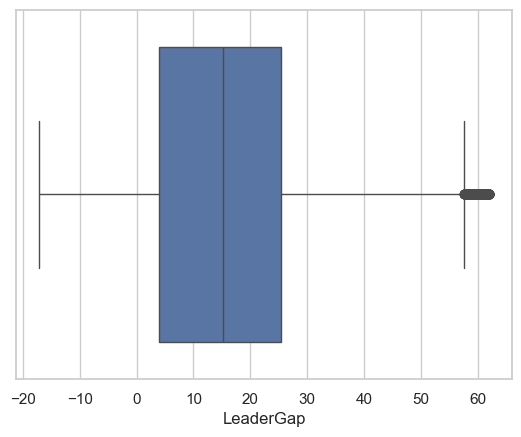

In [24]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = data.LeaderGap, orient = 'h')

In [25]:
percentile25 = data['LeaderGap'].quantile(0.25)
percentile75 = data['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Upper limit
upper_limit = data['LeaderGap'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)
#Lower limit
lower_limit = data['LeaderGap'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)

75th quartile:  25.42
25th quartile:  3.92
IQR:  21.5
Upper_limit:  57.67
Lower_limit:  -28.33


In [26]:
datas = data[~((data.LeaderGap < lower_limit)|(data.LeaderGap > upper_limit))]
datas

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99
...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85


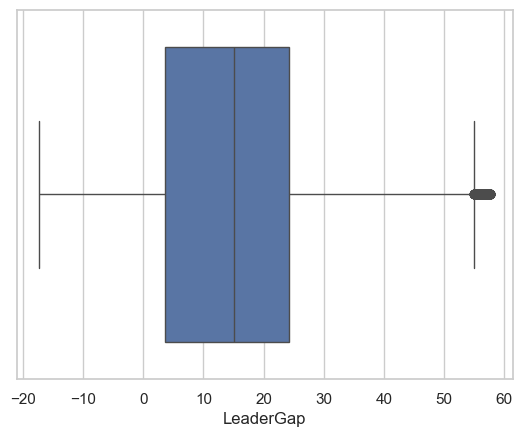

In [27]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = datas.LeaderGap, orient = 'h')

In [28]:
percentile25 = datas['LeaderGap'].quantile(0.25)
percentile75 = datas['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Upper limit
upper_limit = datas['LeaderGap'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)
#Lower limit
lower_limit = datas['LeaderGap'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)

75th quartile:  24.134999999999998
25th quartile:  3.57
IQR:  20.564999999999998
Upper_limit:  54.982499999999995
Lower_limit:  -27.277499999999996


In [29]:
dtt = datas[~((datas.LeaderGap < lower_limit)|(datas.LeaderGap > upper_limit))]
dtt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99
...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85


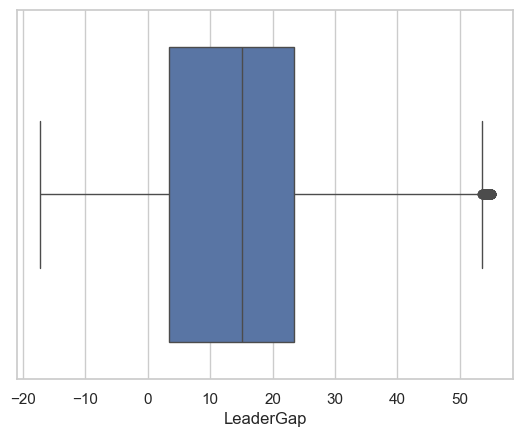

In [30]:
sns.set(style='whitegrid')
ax = sns.boxplot(data = dtt.LeaderGap, orient = 'h')

In [31]:
percentile25 = dtt['LeaderGap'].quantile(0.25)
percentile75 = dtt['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Upper limit
upper_limit = dtt['LeaderGap'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)
#Lower limit
lower_limit = dtt['LeaderGap'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)

75th quartile:  23.48
25th quartile:  3.3925
IQR:  20.0875
Upper_limit:  53.61125
Lower_limit:  -26.738749999999996


In [32]:
dtts = dtt[~((dtt.LeaderGap < lower_limit)|(dtt.LeaderGap > upper_limit))]
dtts

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99
...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85


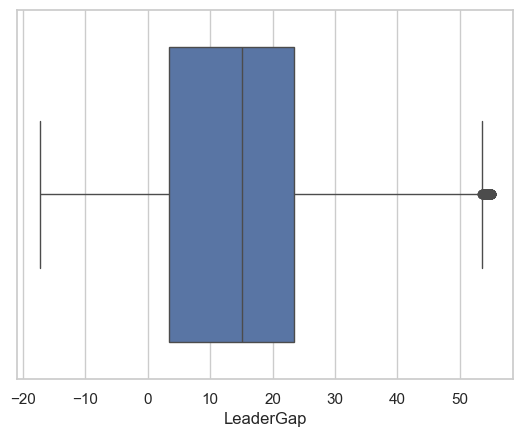

In [33]:
sns.set(style='whitegrid')
ax = sns.boxplot(data = dtt.LeaderGap, orient = 'h')

In [34]:
percentile25 = dtts['LeaderGap'].quantile(0.25)
percentile75 = dtts['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Upper limit
upper_limit = dtts['LeaderGap'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)
#Lower limit
lower_limit = dtts['LeaderGap'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)

75th quartile:  23.13
25th quartile:  3.3049999999999997
IQR:  19.825
Upper_limit:  52.86749999999999
Lower_limit:  -26.432499999999997


In [35]:
dataset = dtts[~((dtts.LeaderGap < lower_limit)|(dtts.LeaderGap > upper_limit))]
dataset

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99
...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85


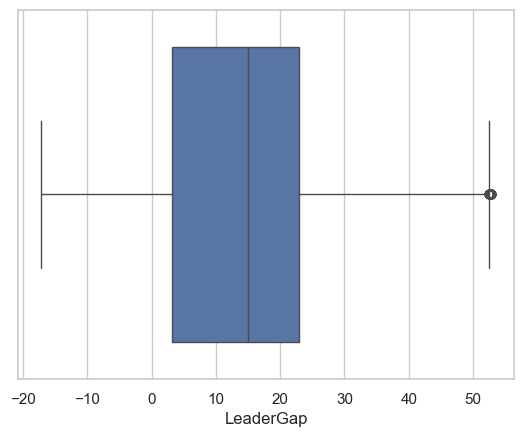

In [36]:
sns.set(style='whitegrid')
ax = sns.boxplot(data = dataset.LeaderGap, orient = 'h')

In [37]:
dataset["Deceleration"] = dataset["Acceleration"].apply(lambda a: -a if a < 0 else 0)
dataset

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97,0.00
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91,0.00
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49,0.00
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32,0.00
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99,0.00
...,...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30,0.00
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26,0.00
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61,5.61
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85,4.85


In [38]:
dataset["RelativeSpeed"] = dataset["Speed"] - dataset["LeaderSpeed"]
dataset

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97,0.00,13.59
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91,0.00,1.25
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49,0.00,1.49
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32,0.00,1.73
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99,0.00,1.95
...,...,...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30,0.00,14.82
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26,0.00,-0.03
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61,5.61,15.42
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85,4.85,14.73


In [39]:
def compute_ttc(row):
    # Pas de leader ou gap <= 0 => TTC = 999 (valeur arbitraire)
    if row["LeaderID"] == -1 or row["LeaderGap"] <= 0:
        return 999
    
    # RelativeSpeed <= 0 => pas de collision => TTC = 999
    if row["RelativeSpeed"] <= 0:
        return 999
    
    # Formule de base
    return row["LeaderGap"] / row["RelativeSpeed"]

In [40]:
dataset["TTC"] = dataset.apply(compute_ttc, axis=1)
dataset

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed,TTC
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97,0.00,13.59,999.000000
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91,0.00,1.25,999.000000
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49,0.00,1.49,999.000000
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32,0.00,1.73,999.000000
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99,0.00,1.95,999.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30,0.00,14.82,999.000000
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26,0.00,-0.03,999.000000
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61,5.61,15.42,999.000000
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85,4.85,14.73,999.000000


In [41]:
dataset['SafeUnsafeCrossing'] = np.where(
    ((dataset['LeaderGap'] != -1) & (dataset['LeaderGap'] < 2.5)) |
    (dataset['Deceleration'] < -4.5) |
    (dataset['Acceleration'] > 2.6) |
    ((dataset['TTC'] < 1.5) & ((dataset['TTC'] > 3) & (dataset['TTC'] != 999))) |
    (dataset['RelativeSpeed'] > 30),
    0, 1)
dataset

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed,TTC,SafeUnsafeCrossing
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.00,-1.00,6.97,0.00,13.59,999.000000,0
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.00,-1.00,4.91,0.00,1.25,999.000000,0
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.00,-1.00,5.49,0.00,1.49,999.000000,0
3,0.3,0,0.75,1172.35,0.73,3.626090e+10,-1,-1.00,-1.00,5.32,0.00,1.73,999.000000,0
4,0.4,0,0.79,1172.26,0.95,3.626090e+10,-1,-1.00,-1.00,4.99,0.00,1.95,999.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57466,199.9,47,817.65,276.51,13.82,3.362609e+11,-1,-1.00,-1.00,5.30,0.00,14.82,999.000000,0
57467,199.9,52,1003.47,55.91,14.46,3.626090e+10,45,14.49,1.24,5.26,0.00,-0.03,999.000000,0
57468,199.9,45,1018.61,37.71,14.42,3.626090e+10,-1,-1.00,-1.00,-5.61,5.61,15.42,999.000000,1
57469,200.0,47,816.79,277.58,13.73,3.362609e+11,-1,-1.00,-1.00,-4.85,4.85,14.73,999.000000,1


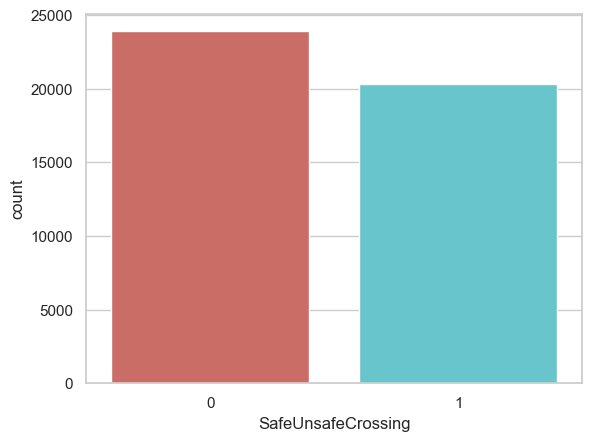

In [42]:
sns.countplot(x='SafeUnsafeCrossing', data=dataset, palette='hls')
plt.rcParams["figure.figsize"] = [2,5]
plt.show()

In [43]:
X_features_input = dataset.iloc[:,0:13] #features[rows, columms]
y_label_output = dataset.iloc[:,13]
X_features_input.head(3)

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed,TTC
0,0.0,0,0.69,1172.48,12.59,3.626090e+10,-1,-1.0,-1.0,6.97,0.0,13.59,999.0
1,0.1,0,0.70,1172.46,0.25,3.626090e+10,-1,-1.0,-1.0,4.91,0.0,1.25,999.0
2,0.2,0,0.72,1172.41,0.49,3.626090e+10,-1,-1.0,-1.0,5.49,0.0,1.49,999.0


In [44]:
y_label_output.head(2)

0    0
1    0
Name: SafeUnsafeCrossing, dtype: int32

In [45]:
missing_data = dataset.isnull()
missing_data

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed,TTC,SafeUnsafeCrossing
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57466,False,False,False,False,False,False,False,False,False,False,False,False,False,False
57467,False,False,False,False,False,False,False,False,False,False,False,False,False,False
57468,False,False,False,False,False,False,False,False,False,False,False,False,False,False
57469,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [46]:
#VarianceThreshold removes the features whose variance doesn't meet the given threshold value
vt=VarianceThreshold(threshold=0)
vt.fit(dataset)

VarianceThreshold(threshold=0)

In [47]:
dataset=vt.transform(dataset)
dataset.shape

(44176, 14)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_features_input, y_label_output, test_size=0.2, random_state=100)

In [49]:
X_train.shape

(35340, 13)

In [50]:
X_test.shape

(8836, 13)

In [51]:
y_label_output.mean()

0.4592538935168417

In [52]:
print(y_train.mean())
print(y_test.mean())

0.45916808149405774
0.4595971027614305


In [53]:
# StandarScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [54]:
rf = RandomForestClassifier()
rf.fit(X_train_sc, y_train)
y_predRF = rf.predict(X_test_sc)

In [55]:
print('Confusion matrix rf \n', confusion_matrix(y_test,y_predRF))
print('Accuracy rf', accuracy_score(y_test,y_predRF))
print('Recall rf', recall_score(y_test,y_predRF))
print('Precision rf', precision_score(y_test,y_predRF))

Confusion matrix rf 
 [[4774    1]
 [   0 4061]]
Accuracy rf 0.9998868266183794
Recall rf 1.0
Precision rf 0.9997538158542589


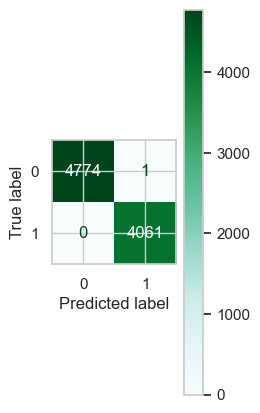

In [56]:
cm = confusion_matrix(y_test, y_predRF, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=rf.classes_)
disp.plot(cmap=plt.cm.BuGn)
plt.show()

# OVERTAKING

In [57]:
data = pd.read_csv('overtakingsansobjet.csv')
data

,Time,VehicleId,Pos_x,Pos_y,Type,Speed,Lane,Slope,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,10101,-100.00,-1.60,obstacle,0.00,west_right_0,0.0,-1.0,-1.00,-1.00,0.00
1,0.1,10101,-99.97,-1.60,obstacle,0.30,west_right_0,0.0,-1.0,-1.00,-1.00,2.99
2,0.2,10101,-99.91,-1.60,obstacle,0.59,west_right_0,0.0,-1.0,-1.00,-1.00,2.89
3,0.3,10101,-99.83,-1.60,obstacle,0.84,west_right_0,0.0,-1.0,-1.00,-1.00,2.57
4,0.4,10101,-99.72,-1.60,obstacle,1.10,west_right_0,0.0,-1.0,-1.00,-1.00,2.57
...,...,...,...,...,...,...,...,...,...,...,...,...
27531,129.9,60,54.45,-1.60,type2,12.02,east_right_0,0.0,39.0,12.69,14.02,0.43
27532,129.9,61,-1.60,68.21,type1,6.74,north_down_0,0.0,58.0,8.04,13.27,-0.84
27533,129.9,64,-1.60,-18.02,type4,6.76,south_down_0,0.0,54.0,7.25,9.35,-0.18
27534,129.9,68,-1.60,81.46,type2,5.95,north_down_0,0.0,61.0,6.74,8.25,1.09


In [58]:
dt = data.drop(labels=['Slope', 'Type'], axis=1)
dt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,10101,-100.00,-1.60,0.00,west_right_0,-1.0,-1.00,-1.00,0.00
1,0.1,10101,-99.97,-1.60,0.30,west_right_0,-1.0,-1.00,-1.00,2.99
2,0.2,10101,-99.91,-1.60,0.59,west_right_0,-1.0,-1.00,-1.00,2.89
3,0.3,10101,-99.83,-1.60,0.84,west_right_0,-1.0,-1.00,-1.00,2.57
4,0.4,10101,-99.72,-1.60,1.10,west_right_0,-1.0,-1.00,-1.00,2.57
...,...,...,...,...,...,...,...,...,...,...
27531,129.9,60,54.45,-1.60,12.02,east_right_0,39.0,12.69,14.02,0.43
27532,129.9,61,-1.60,68.21,6.74,north_down_0,58.0,8.04,13.27,-0.84
27533,129.9,64,-1.60,-18.02,6.76,south_down_0,54.0,7.25,9.35,-0.18
27534,129.9,68,-1.60,81.46,5.95,north_down_0,61.0,6.74,8.25,1.09


In [59]:
dt.dtypes

Time            float64
VehicleId         int64
Pos_x           float64
Pos_y           float64
Speed           float64
Lane             object
LeaderID        float64
LeaderSpeed     float64
LeaderGap       float64
Acceleration    float64
dtype: object

In [60]:
from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'Lane' column
dt['Lane'] = label_encoder.fit_transform(dt['Lane'])

print(dt)

        Time  VehicleId   Pos_x  Pos_y  Speed  Lane  LeaderID  LeaderSpeed  \
0        0.0      10101 -100.00  -1.60   0.00    21      -1.0        -1.00   
1        0.1      10101  -99.97  -1.60   0.30    21      -1.0        -1.00   
2        0.2      10101  -99.91  -1.60   0.59    21      -1.0        -1.00   
3        0.3      10101  -99.83  -1.60   0.84    21      -1.0        -1.00   
4        0.4      10101  -99.72  -1.60   1.10    21      -1.0        -1.00   
...      ...        ...     ...    ...    ...   ...       ...          ...   
27531  129.9         60   54.45  -1.60  12.02    15      39.0        12.69   
27532  129.9         61   -1.60  68.21   6.74    16      58.0         8.04   
27533  129.9         64   -1.60 -18.02   6.76    18      54.0         7.25   
27534  129.9         68   -1.60  81.46   5.95    16      61.0         6.74   
27535  129.9         70   -1.60  92.82   2.83    16      68.0         5.95   

       LeaderGap  Acceleration  
0          -1.00          0.00

In [61]:
dt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,10101,-100.00,-1.60,0.00,21,-1.0,-1.00,-1.00,0.00
1,0.1,10101,-99.97,-1.60,0.30,21,-1.0,-1.00,-1.00,2.99
2,0.2,10101,-99.91,-1.60,0.59,21,-1.0,-1.00,-1.00,2.89
3,0.3,10101,-99.83,-1.60,0.84,21,-1.0,-1.00,-1.00,2.57
4,0.4,10101,-99.72,-1.60,1.10,21,-1.0,-1.00,-1.00,2.57
...,...,...,...,...,...,...,...,...,...,...
27531,129.9,60,54.45,-1.60,12.02,15,39.0,12.69,14.02,0.43
27532,129.9,61,-1.60,68.21,6.74,16,58.0,8.04,13.27,-0.84
27533,129.9,64,-1.60,-18.02,6.76,18,54.0,7.25,9.35,-0.18
27534,129.9,68,-1.60,81.46,5.95,16,61.0,6.74,8.25,1.09


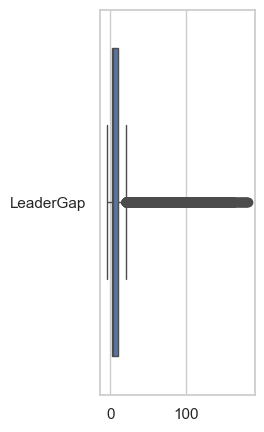

In [62]:
#my_list = ['LeaderGap', 'LeaderSpeed', 'Acceleration']
my_list = ['LeaderGap']
sns.set(style='whitegrid')
ax = sns.boxplot(data = dt[my_list], orient = 'h')

In [63]:
percentile25 = dt['LeaderGap'].quantile(0.25)
percentile75 = dt['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  9.8025
25th quartile:  2.4475000000000002


In [64]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)

IQR:  7.355


In [65]:
lower_limit = dt['LeaderGap'].quantile(0.25)-1.5*iqr
lower_limit

-8.585

In [66]:
upper_limit = dt['LeaderGap'].quantile(0.75)+1.5*iqr
upper_limit

20.835

In [67]:
dt[(dt.LeaderGap > upper_limit) | (dt.LeaderGap < lower_limit)]

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
311,7.1,6,-1.60,94.50,3.99,16,5.0,10.80,21.16,39.88
319,7.2,6,-1.60,93.72,7.79,16,5.0,10.70,21.45,38.06
327,7.3,6,-1.60,92.58,11.42,16,5.0,10.58,21.36,36.26
335,7.4,6,-1.60,91.40,11.81,16,5.0,11.09,21.29,3.88
338,7.5,1,-87.85,-1.60,4.55,21,10101.0,0.00,22.85,1.73
...,...,...,...,...,...,...,...,...,...,...
27512,129.8,55,-1.15,4.02,13.40,6,60.0,11.97,52.03,40.00
27513,129.8,57,-1.60,35.12,8.48,16,55.0,13.40,26.13,-1.26
27525,129.9,45,-24.19,1.60,11.89,20,38.0,13.63,52.01,-5.01
27528,129.9,55,-0.58,2.57,15.87,6,60.0,12.02,51.64,24.70


In [68]:
dt[(dt.LeaderGap > upper_limit) & (dt.LeaderGap < lower_limit)]

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration


In [69]:
newdata = dt[~((dt.LeaderGap < lower_limit)|(dt.LeaderGap > upper_limit))]
newdata

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,10101,-100.00,-1.60,0.00,21,-1.0,-1.00,-1.00,0.00
1,0.1,10101,-99.97,-1.60,0.30,21,-1.0,-1.00,-1.00,2.99
2,0.2,10101,-99.91,-1.60,0.59,21,-1.0,-1.00,-1.00,2.89
3,0.3,10101,-99.83,-1.60,0.84,21,-1.0,-1.00,-1.00,2.57
4,0.4,10101,-99.72,-1.60,1.10,21,-1.0,-1.00,-1.00,2.57
...,...,...,...,...,...,...,...,...,...,...
27531,129.9,60,54.45,-1.60,12.02,15,39.0,12.69,14.02,0.43
27532,129.9,61,-1.60,68.21,6.74,16,58.0,8.04,13.27,-0.84
27533,129.9,64,-1.60,-18.02,6.76,18,54.0,7.25,9.35,-0.18
27534,129.9,68,-1.60,81.46,5.95,16,61.0,6.74,8.25,1.09


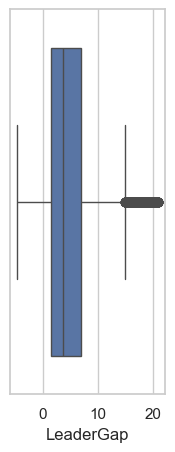

In [70]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = newdata.LeaderGap, orient = 'h')

In [71]:
percentile25 = newdata['LeaderGap'].quantile(0.25)
percentile75 = newdata['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  6.87
25th quartile:  1.5


In [72]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Lower limit
lower_limit = newdata['LeaderGap'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)
#Upper limit
upper_limit = newdata['LeaderGap'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)

IQR:  5.37
Lower_limit:  -6.555
Upper_limit:  14.925


In [73]:
df = newdata[~((newdata.LeaderGap < lower_limit) | (newdata.LeaderGap > upper_limit))]
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,10101,-100.00,-1.60,0.00,21,-1.0,-1.00,-1.00,0.00
1,0.1,10101,-99.97,-1.60,0.30,21,-1.0,-1.00,-1.00,2.99
2,0.2,10101,-99.91,-1.60,0.59,21,-1.0,-1.00,-1.00,2.89
3,0.3,10101,-99.83,-1.60,0.84,21,-1.0,-1.00,-1.00,2.57
4,0.4,10101,-99.72,-1.60,1.10,21,-1.0,-1.00,-1.00,2.57
...,...,...,...,...,...,...,...,...,...,...
27531,129.9,60,54.45,-1.60,12.02,15,39.0,12.69,14.02,0.43
27532,129.9,61,-1.60,68.21,6.74,16,58.0,8.04,13.27,-0.84
27533,129.9,64,-1.60,-18.02,6.76,18,54.0,7.25,9.35,-0.18
27534,129.9,68,-1.60,81.46,5.95,16,61.0,6.74,8.25,1.09


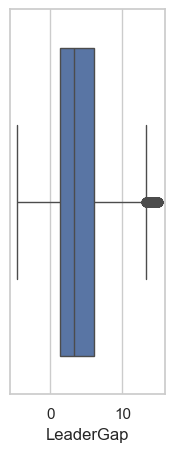

In [74]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = df.LeaderGap, orient = 'h')

In [75]:
percentile25 = df['LeaderGap'].quantile(0.25)
percentile75 = df['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Upper limit
upper_limit = df['LeaderGap'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)
#Lower limit
lower_limit = df['LeaderGap'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)

75th quartile:  6.08
25th quartile:  1.2850000000000001
IQR:  4.795
Upper_limit:  13.2725
Lower_limit:  -5.9075


In [76]:
dt = df[~((df.LeaderGap < lower_limit)|(df.LeaderGap > upper_limit))]
dt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,10101,-100.00,-1.60,0.00,21,-1.0,-1.00,-1.00,0.00
1,0.1,10101,-99.97,-1.60,0.30,21,-1.0,-1.00,-1.00,2.99
2,0.2,10101,-99.91,-1.60,0.59,21,-1.0,-1.00,-1.00,2.89
3,0.3,10101,-99.83,-1.60,0.84,21,-1.0,-1.00,-1.00,2.57
4,0.4,10101,-99.72,-1.60,1.10,21,-1.0,-1.00,-1.00,2.57
...,...,...,...,...,...,...,...,...,...,...
27530,129.9,58,-1.60,49.95,8.04,16,57.0,9.17,10.75,-2.12
27532,129.9,61,-1.60,68.21,6.74,16,58.0,8.04,13.27,-0.84
27533,129.9,64,-1.60,-18.02,6.76,18,54.0,7.25,9.35,-0.18
27534,129.9,68,-1.60,81.46,5.95,16,61.0,6.74,8.25,1.09


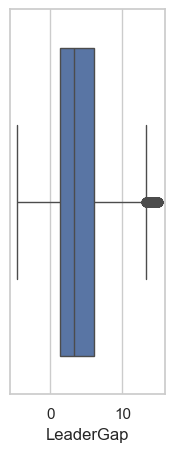

In [77]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = df.LeaderGap, orient = 'h')

In [78]:
percentile25 = dt['LeaderGap'].quantile(0.25)
percentile75 = dt['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Upper limit
upper_limit = dt['LeaderGap'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)
#Lower limit
lower_limit = dt['LeaderGap'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)

75th quartile:  5.78
25th quartile:  -1.0
IQR:  6.78
Upper_limit:  15.95
Lower_limit:  -11.17


In [79]:
df = dt[~((df.LeaderGap < lower_limit)|(dt.LeaderGap > upper_limit))]
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration
0,0.0,10101,-100.00,-1.60,0.00,21,-1.0,-1.00,-1.00,0.00
1,0.1,10101,-99.97,-1.60,0.30,21,-1.0,-1.00,-1.00,2.99
2,0.2,10101,-99.91,-1.60,0.59,21,-1.0,-1.00,-1.00,2.89
3,0.3,10101,-99.83,-1.60,0.84,21,-1.0,-1.00,-1.00,2.57
4,0.4,10101,-99.72,-1.60,1.10,21,-1.0,-1.00,-1.00,2.57
...,...,...,...,...,...,...,...,...,...,...
27530,129.9,58,-1.60,49.95,8.04,16,57.0,9.17,10.75,-2.12
27532,129.9,61,-1.60,68.21,6.74,16,58.0,8.04,13.27,-0.84
27533,129.9,64,-1.60,-18.02,6.76,18,54.0,7.25,9.35,-0.18
27534,129.9,68,-1.60,81.46,5.95,16,61.0,6.74,8.25,1.09


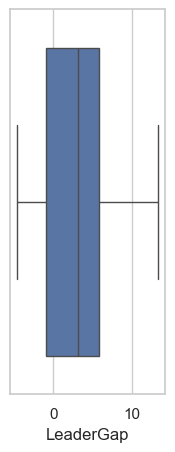

In [80]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = df.LeaderGap, orient = 'h')

In [81]:
df["Deceleration"] = df["Acceleration"].apply(lambda a: -a if a < 0 else 0)
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration
0,0.0,10101,-100.00,-1.60,0.00,21,-1.0,-1.00,-1.00,0.00,0.00
1,0.1,10101,-99.97,-1.60,0.30,21,-1.0,-1.00,-1.00,2.99,0.00
2,0.2,10101,-99.91,-1.60,0.59,21,-1.0,-1.00,-1.00,2.89,0.00
3,0.3,10101,-99.83,-1.60,0.84,21,-1.0,-1.00,-1.00,2.57,0.00
4,0.4,10101,-99.72,-1.60,1.10,21,-1.0,-1.00,-1.00,2.57,0.00
...,...,...,...,...,...,...,...,...,...,...,...
27530,129.9,58,-1.60,49.95,8.04,16,57.0,9.17,10.75,-2.12,2.12
27532,129.9,61,-1.60,68.21,6.74,16,58.0,8.04,13.27,-0.84,0.84
27533,129.9,64,-1.60,-18.02,6.76,18,54.0,7.25,9.35,-0.18,0.18
27534,129.9,68,-1.60,81.46,5.95,16,61.0,6.74,8.25,1.09,0.00


In [82]:
df["RelativeSpeed"] = df["Speed"] - df["LeaderSpeed"]
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed
0,0.0,10101,-100.00,-1.60,0.00,21,-1.0,-1.00,-1.00,0.00,0.00,1.00
1,0.1,10101,-99.97,-1.60,0.30,21,-1.0,-1.00,-1.00,2.99,0.00,1.30
2,0.2,10101,-99.91,-1.60,0.59,21,-1.0,-1.00,-1.00,2.89,0.00,1.59
3,0.3,10101,-99.83,-1.60,0.84,21,-1.0,-1.00,-1.00,2.57,0.00,1.84
4,0.4,10101,-99.72,-1.60,1.10,21,-1.0,-1.00,-1.00,2.57,0.00,2.10
...,...,...,...,...,...,...,...,...,...,...,...,...
27530,129.9,58,-1.60,49.95,8.04,16,57.0,9.17,10.75,-2.12,2.12,-1.13
27532,129.9,61,-1.60,68.21,6.74,16,58.0,8.04,13.27,-0.84,0.84,-1.30
27533,129.9,64,-1.60,-18.02,6.76,18,54.0,7.25,9.35,-0.18,0.18,-0.49
27534,129.9,68,-1.60,81.46,5.95,16,61.0,6.74,8.25,1.09,0.00,-0.79


In [83]:
def compute_ttc(row):
    # Pas de leader ou gap <= 0 => TTC = 999 (valeur arbitraire)
    if row["LeaderID"] == -1 or row["LeaderGap"] <= 0:
        return 999
    
    # RelativeSpeed <= 0 => pas de collision => TTC = 999
    if row["RelativeSpeed"] <= 0:
        return 999
    
    # Formule de base
    return row["LeaderGap"] / row["RelativeSpeed"]

In [84]:
df["TTC"] = df.apply(compute_ttc, axis=1)
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed,TTC
0,0.0,10101,-100.00,-1.60,0.00,21,-1.0,-1.00,-1.00,0.00,0.00,1.00,999.0
1,0.1,10101,-99.97,-1.60,0.30,21,-1.0,-1.00,-1.00,2.99,0.00,1.30,999.0
2,0.2,10101,-99.91,-1.60,0.59,21,-1.0,-1.00,-1.00,2.89,0.00,1.59,999.0
3,0.3,10101,-99.83,-1.60,0.84,21,-1.0,-1.00,-1.00,2.57,0.00,1.84,999.0
4,0.4,10101,-99.72,-1.60,1.10,21,-1.0,-1.00,-1.00,2.57,0.00,2.10,999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27530,129.9,58,-1.60,49.95,8.04,16,57.0,9.17,10.75,-2.12,2.12,-1.13,999.0
27532,129.9,61,-1.60,68.21,6.74,16,58.0,8.04,13.27,-0.84,0.84,-1.30,999.0
27533,129.9,64,-1.60,-18.02,6.76,18,54.0,7.25,9.35,-0.18,0.18,-0.49,999.0
27534,129.9,68,-1.60,81.46,5.95,16,61.0,6.74,8.25,1.09,0.00,-0.79,999.0


In [85]:
df['SafeDistance'] = (df['Speed']/10)*3
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed,TTC,SafeDistance
0,0.0,10101,-100.00,-1.60,0.00,21,-1.0,-1.00,-1.00,0.00,0.00,1.00,999.0,0.000
1,0.1,10101,-99.97,-1.60,0.30,21,-1.0,-1.00,-1.00,2.99,0.00,1.30,999.0,0.090
2,0.2,10101,-99.91,-1.60,0.59,21,-1.0,-1.00,-1.00,2.89,0.00,1.59,999.0,0.177
3,0.3,10101,-99.83,-1.60,0.84,21,-1.0,-1.00,-1.00,2.57,0.00,1.84,999.0,0.252
4,0.4,10101,-99.72,-1.60,1.10,21,-1.0,-1.00,-1.00,2.57,0.00,2.10,999.0,0.330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27530,129.9,58,-1.60,49.95,8.04,16,57.0,9.17,10.75,-2.12,2.12,-1.13,999.0,2.412
27532,129.9,61,-1.60,68.21,6.74,16,58.0,8.04,13.27,-0.84,0.84,-1.30,999.0,2.022
27533,129.9,64,-1.60,-18.02,6.76,18,54.0,7.25,9.35,-0.18,0.18,-0.49,999.0,2.028
27534,129.9,68,-1.60,81.46,5.95,16,61.0,6.74,8.25,1.09,0.00,-0.79,999.0,1.785


In [86]:
df['SafeDistance'] = df['SafeDistance'].replace([np.inf, -np.inf], np.nan)  # Remplacer inf par NaN
df['SafeDistance'] = df['SafeDistance'].fillna(999)  # Remplacer NaN par 999.0
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed,TTC,SafeDistance
0,0.0,10101,-100.00,-1.60,0.00,21,-1.0,-1.00,-1.00,0.00,0.00,1.00,999.0,0.000
1,0.1,10101,-99.97,-1.60,0.30,21,-1.0,-1.00,-1.00,2.99,0.00,1.30,999.0,0.090
2,0.2,10101,-99.91,-1.60,0.59,21,-1.0,-1.00,-1.00,2.89,0.00,1.59,999.0,0.177
3,0.3,10101,-99.83,-1.60,0.84,21,-1.0,-1.00,-1.00,2.57,0.00,1.84,999.0,0.252
4,0.4,10101,-99.72,-1.60,1.10,21,-1.0,-1.00,-1.00,2.57,0.00,2.10,999.0,0.330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27530,129.9,58,-1.60,49.95,8.04,16,57.0,9.17,10.75,-2.12,2.12,-1.13,999.0,2.412
27532,129.9,61,-1.60,68.21,6.74,16,58.0,8.04,13.27,-0.84,0.84,-1.30,999.0,2.022
27533,129.9,64,-1.60,-18.02,6.76,18,54.0,7.25,9.35,-0.18,0.18,-0.49,999.0,2.028
27534,129.9,68,-1.60,81.46,5.95,16,61.0,6.74,8.25,1.09,0.00,-0.79,999.0,1.785


In [87]:
df["LanePrev"] = df.groupby("VehicleId")["Lane"].shift(1).fillna(999)

In [88]:
df.fillna(999, inplace=True)


In [89]:
# up = north_up_0 (17), south_up_0 (19)
up_lanes = [17, 19]

# down = north_down_0 (16), south_down_0 (18)
down_lanes = [16, 18]

# left = west_left_0 (20), east_left_0 (14)
left_lanes = [20, 14]

# right = west_right_0 (21), east_right_0 (15)
right_lanes = [21, 15]

In [90]:
df["lane_opposite_change"] = (
    # up → down
    (df["Lane"].isin(up_lanes) & df["LanePrev"].isin(down_lanes))
    |
    # down → up
    (df["Lane"].isin(down_lanes) & df["LanePrev"].isin(up_lanes))
    |
    # left → right
    (df["Lane"].isin(left_lanes) & df["LanePrev"].isin(right_lanes))
    |
    # right → left
    (df["Lane"].isin(right_lanes) & df["LanePrev"].isin(left_lanes))
)

In [91]:
df["SafeUnsafeOvertaking"] = np.where(
    (
        ((df['LeaderGap'] != -1) & (df['LeaderGap'] < 2.5))
        | (df['Deceleration'] > 4.5)
        | (df['Acceleration'] > 2.6)
        | ((df['TTC'] < 1.5) & (df['TTC'] > 3) & (df['TTC'] != 999))
        | (df['RelativeSpeed'] > 30)
        | (df["lane_opposite_change"])
        | (df['LeaderGap'] < df['SafeDistance'])       
    ),
    0,  # unsafe
    1   # safe
)

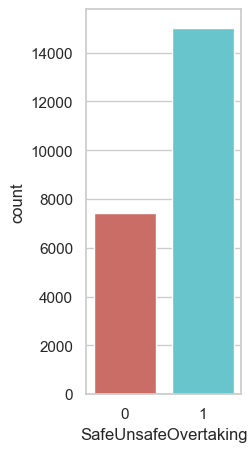

In [92]:
sns.countplot(x='SafeUnsafeOvertaking', data=df, palette='hls')
plt.rcParams["figure.figsize"] = [2,5]
plt.show()

In [93]:
from imblearn.over_sampling import SMOTE
# Supprimer la colonne cible pour obtenir les features
X = df.drop(columns=['SafeUnsafeOvertaking'])
# Sélectionner la colonne cible
y = df['SafeUnsafeOvertaking']

# On utilise un ratio plus faible (ex. 0.5) pour limiter la création d'exemples synthétiques.
# Cela veut dire que la classe minoritaire atteindra la moitié de la taille de la classe majoritaire.
sm = SMOTE(random_state=42, sampling_strategy=0.8)
X_sm, y_sm = sm.fit_resample(X, y)

# Reconstruire un DataFrame
df_sm = pd.DataFrame(X_sm, columns=X.columns)
df_sm['SafeUnsafeOvertaking'] = y_sm

# Afficher un aperçu
df_sm.head()

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed,TTC,SafeDistance,LanePrev,lane_opposite_change,SafeUnsafeOvertaking
0,0.0,10101,-100.00,-1.6,0.00,21,-1.0,-1.0,-1.0,0.00,0.0,1.00,999.0,0.000,999.0,False,0
1,0.1,10101,-99.97,-1.6,0.30,21,-1.0,-1.0,-1.0,2.99,0.0,1.30,999.0,0.090,21.0,False,0
2,0.2,10101,-99.91,-1.6,0.59,21,-1.0,-1.0,-1.0,2.89,0.0,1.59,999.0,0.177,21.0,False,0
3,0.3,10101,-99.83,-1.6,0.84,21,-1.0,-1.0,-1.0,2.57,0.0,1.84,999.0,0.252,21.0,False,0
4,0.4,10101,-99.72,-1.6,1.10,21,-1.0,-1.0,-1.0,2.57,0.0,2.10,999.0,0.330,21.0,False,0


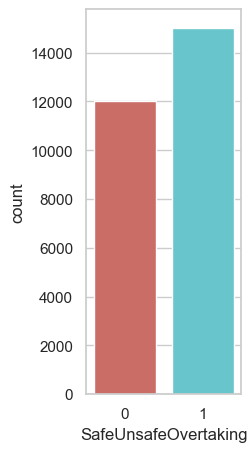

In [94]:
sns.countplot(x='SafeUnsafeOvertaking', data=df_sm, palette='hls')
plt.rcParams["figure.figsize"] = [2,5]
plt.show()

In [95]:
X_features_input = df_sm.iloc[:,0:16] #features[rows, columms]
y_label_output = df_sm.iloc[:,16]
X_features_input.head(3)

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed,TTC,SafeDistance,LanePrev,lane_opposite_change
0,0.0,10101,-100.00,-1.6,0.00,21,-1.0,-1.0,-1.0,0.00,0.0,1.00,999.0,0.000,999.0,False
1,0.1,10101,-99.97,-1.6,0.30,21,-1.0,-1.0,-1.0,2.99,0.0,1.30,999.0,0.090,21.0,False
2,0.2,10101,-99.91,-1.6,0.59,21,-1.0,-1.0,-1.0,2.89,0.0,1.59,999.0,0.177,21.0,False


In [96]:
y_label_output.head(2)

0    0
1    0
Name: SafeUnsafeOvertaking, dtype: int32

In [97]:
missing_data = df_sm.isnull()
missing_data

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,LeaderID,LeaderSpeed,LeaderGap,Acceleration,Deceleration,RelativeSpeed,TTC,SafeDistance,LanePrev,lane_opposite_change,SafeUnsafeOvertaking
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27050,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
27051,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
27052,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
27053,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [98]:
X_train, X_test, y_train, y_test = train_test_split(X_features_input, y_label_output, test_size=0.3, random_state=100)

In [99]:
X_train.shape

(18938, 16)

In [100]:
X_test.shape

(8117, 16)

In [101]:
# StandarScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [102]:
kernel_SVM = SVC(kernel='rbf')
kernel_SVM.fit(X_train_sc,y_train)
y_predictSVM_rbf = kernel_SVM.predict(X_test_sc)

In [103]:
print('Confusion matrix rbf SVM \n', confusion_matrix(y_test,y_predictSVM_rbf))
count_misclassified = (y_test != y_predictSVM_rbf).sum()
print('Misclassified samples: {}'.format(count_misclassified))
print('Accuracy rbf SVM:', accuracy_score(y_test,y_predictSVM_rbf)*100.0)
print('Precision rbf SVM: ', precision_score(y_test,y_predictSVM_rbf)*100.0)
print('Recall rbf SVM:', recall_score(y_test,y_predictSVM_rbf)*100.0)

Confusion matrix rbf SVM 
 [[3528   49]
 [  12 4528]]
Misclassified samples: 61
Accuracy rbf SVM: 99.24849082173218
Precision rbf SVM:  98.92942975748306
Recall rbf SVM: 99.73568281938327


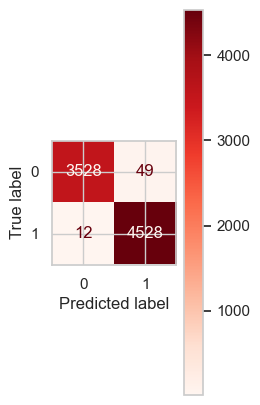

In [104]:
cm = confusion_matrix(y_test, y_predictSVM_rbf, labels=kernel_SVM.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=kernel_SVM.classes_)
disp.plot(cmap=plt.cm.Reds)
plt.show()

# DANGER_ZONE

In [105]:
data = pd.read_csv('outputDZD.csv')
data

,Time,VehicleId,Pos_x,Pos_y,Angle,Type,Speed,Lane,Slope,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,90.0,obstacle,0.00,west_right_0,0,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,90.0,obstacle,0.30,west_right_0,0,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,90.0,obstacle,0.59,west_right_0,0,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,90.0,obstacle,0.84,west_right_0,0,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,90.0,obstacle,1.10,west_right_0,0,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,180.0,type3,13.00,south_down_0,0,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,180.0,type3,12.80,south_down_0,0,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,180.0,type3,12.95,south_down_0,0,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,180.0,type3,12.87,south_down_0,0,-0.85,-1,-1.0,-1.0


In [106]:
dt = data.drop(labels=['Slope', 'Angle', 'Type'], axis=1)
dt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,west_right_0,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,west_right_0,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,west_right_0,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,west_right_0,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,west_right_0,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,south_down_0,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,south_down_0,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,south_down_0,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,south_down_0,-0.85,-1,-1.0,-1.0


In [107]:
from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'Lane' column
dt['Lane'] = label_encoder.fit_transform(dt['Lane'])

print(dt)

        Time  VehicleId   Pos_x  Pos_y  Speed  Lane  Acceleration  LeaderID  \
0        0.0      10101 -100.00  -1.60   0.00    21          0.00        -1   
1        0.1      10101  -99.97  -1.60   0.30    21          2.99        -1   
2        0.2      10101  -99.91  -1.60   0.59    21          2.89        -1   
3        0.3      10101  -99.83  -1.60   0.84    21          2.57        -1   
4        0.4      10101  -99.72  -1.60   1.10    21          2.57        -1   
...      ...        ...     ...    ...    ...   ...           ...       ...   
28884  149.2         70   -1.60 -93.89  13.00    18          2.63        -1   
28885  149.3         70   -1.60 -95.17  12.80    18         -2.00        -1   
28886  149.4         70   -1.60 -96.46  12.95    18          1.47        -1   
28887  149.5         70   -1.60 -97.75  12.87    18         -0.85        -1   
28888  149.6         70   -1.60 -99.02  12.67    18         -2.00        -1   

       LeaderSpeed  LeaderGap  
0             -1.0 

In [108]:
dt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


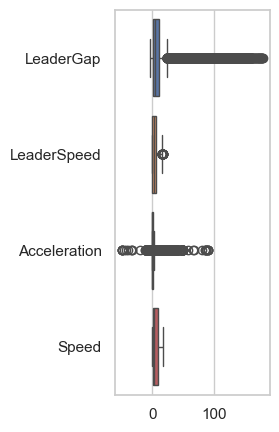

In [109]:
my_list = ['LeaderGap', 'LeaderSpeed', 'Acceleration','Speed']
#my_list = ['leaderGap']
sns.set(style='whitegrid')
ax = sns.boxplot(data = dt[my_list], orient = 'h')

In [110]:
percentile25 = dt['LeaderGap'].quantile(0.25)
percentile75 = dt['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  10.53
25th quartile:  1.5


In [111]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)

IQR:  9.03


In [112]:
lower_limit = dt['LeaderGap'].quantile(0.25)-1.5*iqr
lower_limit

-12.044999999999998

In [113]:
upper_limit = dt['LeaderGap'].quantile(0.75)+1.5*iqr
upper_limit

24.074999999999996

In [114]:
dt[(dt.LeaderGap > upper_limit) & (dt.LeaderGap < lower_limit)]

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap


In [115]:
newdata = dt[~((dt.LeaderGap < lower_limit)|(dt.LeaderGap > upper_limit))]
newdata

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


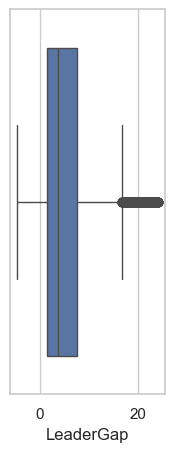

In [116]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = newdata.LeaderGap, orient = 'h')

In [117]:
percentile25 = newdata['LeaderGap'].quantile(0.25)
percentile75 = newdata['LeaderGap'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  7.58
25th quartile:  1.5


In [118]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Lower limit
lower_limit = newdata['LeaderGap'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)
#Upper limit
upper_limit = newdata['LeaderGap'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)

IQR:  6.08
Lower_limit:  -7.620000000000001
Upper_limit:  16.700000000000003


In [119]:
df = newdata[~((newdata.LeaderGap < lower_limit) | (newdata.LeaderGap > upper_limit))]
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


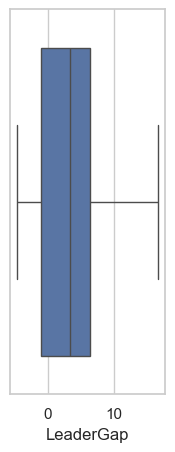

In [120]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = df.LeaderGap, orient = 'h')

In [121]:
percentile25 = df['LeaderSpeed'].quantile(0.25)
percentile75 = df['LeaderSpeed'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  3.65
25th quartile:  -1.0


In [122]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)

IQR:  4.65


In [123]:
lower_limit = df['LeaderSpeed'].quantile(0.25)-1.5*iqr
lower_limit

-7.9750000000000005

In [124]:
upper_limit = df['LeaderSpeed'].quantile(0.75)+1.5*iqr
upper_limit

10.625

In [125]:
df[(df.LeaderSpeed > upper_limit) | (df.LeaderSpeed < lower_limit)]

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
33,2.6,3,94.90,1.60,0.00,14,0.00,2,14.55,3.20
36,2.7,3,94.02,1.60,8.77,14,87.66,2,14.36,3.76
39,2.8,3,92.81,1.60,12.14,14,33.73,2,14.78,4.03
42,2.9,3,91.51,1.60,12.95,14,8.10,2,14.58,4.19
45,3.0,3,90.24,1.60,12.79,14,-1.56,2,14.71,4.38
...,...,...,...,...,...,...,...,...,...,...
28386,136.8,64,-1.60,-76.65,11.07,18,0.61,54,12.46,14.10
28394,136.9,64,-1.60,-77.81,11.60,18,5.28,54,12.24,14.16
28402,137.0,64,-1.60,-78.98,11.66,18,0.62,54,12.00,14.20
28410,137.1,64,-1.60,-80.10,11.22,18,-4.37,54,12.45,14.32


In [126]:
df[(df.LeaderSpeed > upper_limit) & (df.LeaderSpeed < lower_limit)]

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap


In [127]:
newdata = df[~((df.LeaderSpeed < lower_limit)|(df.LeaderSpeed > upper_limit))]
newdata

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


In [128]:
newdata = df[~((df.LeaderSpeed < lower_limit)|(df.LeaderSpeed > upper_limit))]
newdata

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


In [129]:
percentile25 = newdata['LeaderSpeed'].quantile(0.25)
percentile75 = newdata['LeaderSpeed'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  3.2
25th quartile:  -1.0


In [130]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Lower limit
lower_limit = newdata['LeaderSpeed'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)
#Upper limit
upper_limit = newdata['LeaderSpeed'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)

IQR:  4.2
Lower_limit:  -7.300000000000001
Upper_limit:  9.5


In [131]:
df = newdata[~((newdata.LeaderSpeed < lower_limit) | (newdata.LeaderSpeed > upper_limit))]
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


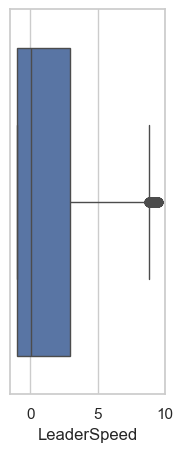

In [132]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = df.LeaderSpeed, orient = 'h')

In [133]:
percentile25 = df['LeaderSpeed'].quantile(0.25)
percentile75 = df['LeaderSpeed'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  2.92
25th quartile:  -1.0


In [134]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Lower limit
lower_limit = df['LeaderSpeed'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)
#Upper limit
upper_limit = df['LeaderSpeed'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)

IQR:  3.92
Lower_limit:  -6.88
Upper_limit:  8.8


In [135]:
dt = df[~((df.LeaderSpeed < lower_limit) | (df.LeaderSpeed > upper_limit))]
dt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


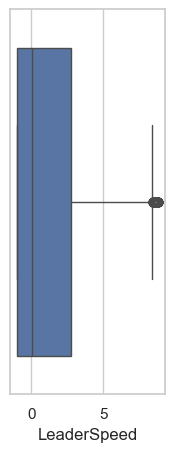

In [136]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = dt.LeaderSpeed, orient = 'h')

In [137]:
percentile25 = dt['LeaderSpeed'].quantile(0.25)
percentile75 = dt['LeaderSpeed'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  2.77
25th quartile:  -1.0


In [138]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Lower limit
lower_limit = dt['LeaderSpeed'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)
#Upper limit
upper_limit = dt['LeaderSpeed'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)

IQR:  3.77
Lower_limit:  -6.655
Upper_limit:  8.425


In [139]:
df = dt[~((dt.LeaderSpeed < lower_limit) | (dt.LeaderSpeed > upper_limit))]
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


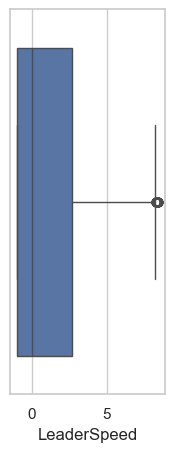

In [140]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = df.LeaderSpeed, orient = 'h')

In [141]:
percentile25 = df['LeaderSpeed'].quantile(0.25)
percentile75 = df['LeaderSpeed'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  2.7
25th quartile:  -1.0


In [142]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Lower limit
lower_limit = df['LeaderSpeed'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)
#Upper limit
upper_limit = df['LeaderSpeed'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)

IQR:  3.7
Lower_limit:  -6.550000000000001
Upper_limit:  8.25


In [143]:
dt = df[~((dt.LeaderSpeed < lower_limit) | (df.LeaderSpeed > upper_limit))]
dt

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


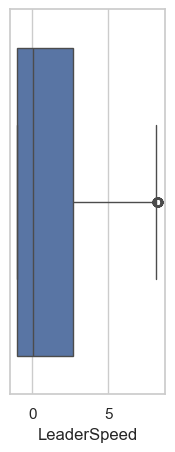

In [144]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = dt.LeaderSpeed, orient = 'h')

In [145]:
percentile25 = dt['LeaderSpeed'].quantile(0.25)
percentile75 = dt['LeaderSpeed'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  2.66
25th quartile:  -1.0


In [146]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Lower limit
lower_limit = dt['LeaderSpeed'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)
#Upper limit
upper_limit = dt['LeaderSpeed'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)

IQR:  3.66
Lower_limit:  -6.49
Upper_limit:  8.15


In [147]:
df = dt[~((dt.LeaderSpeed < lower_limit) | (dt.LeaderSpeed > upper_limit))]
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


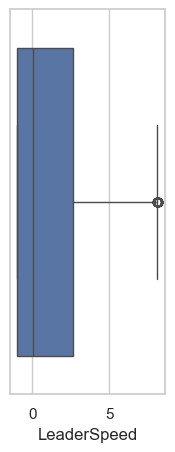

In [148]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = df.LeaderSpeed, orient = 'h')

In [149]:
percentile25 = df['LeaderSpeed'].quantile(0.25)
percentile75 = df['LeaderSpeed'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  2.6425
25th quartile:  -1.0


In [150]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Lower limit
lower_limit = df['LeaderSpeed'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)
#Upper limit
upper_limit = df['LeaderSpeed'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)

IQR:  3.6425
Lower_limit:  -6.46375
Upper_limit:  8.10625


In [151]:
data = df[~((df.LeaderSpeed < lower_limit) | (df.LeaderSpeed > upper_limit))]
data

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


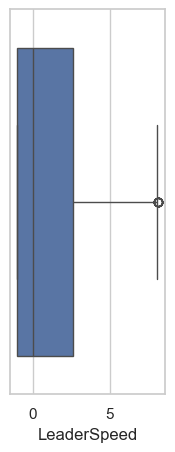

In [152]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = data.LeaderSpeed, orient = 'h')

In [153]:
percentile25 = data['LeaderSpeed'].quantile(0.25)
percentile75 = data['LeaderSpeed'].quantile(0.75)
print("75th quartile: ",percentile75)
print("25th quartile: ",percentile25)

75th quartile:  2.63
25th quartile:  -1.0


In [154]:
iqr = percentile75 - percentile25
print ("IQR: ",iqr)
#Lower limit
lower_limit = data['LeaderSpeed'].quantile(0.25)-1.5*iqr
print ("Lower_limit: ",lower_limit)
#Upper limit
upper_limit = data['LeaderSpeed'].quantile(0.75)+1.5*iqr
print ("Upper_limit: ",upper_limit)

IQR:  3.63
Lower_limit:  -6.445
Upper_limit:  8.075


In [155]:
df = data[~((data.LeaderSpeed < lower_limit) | (data.LeaderSpeed > upper_limit))]
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0


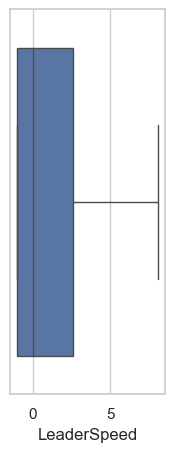

In [156]:
sns.set(style='whitegrid') 
ax = sns.boxplot(data = df.LeaderSpeed, orient = 'h')

In [157]:
df["Deceleration"] = df["Acceleration"].apply(lambda a: -a if a < 0 else 0)
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap,Deceleration
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0,0.00
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0,0.00
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0,0.00
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0,0.00
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0,0.00
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0,2.00
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0,0.00
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0,0.85


In [158]:
df["RelativeSpeed"] = df["Speed"] - df["LeaderSpeed"]
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap,Deceleration,RelativeSpeed
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0,0.00,1.00
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0,0.00,1.30
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0,0.00,1.59
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0,0.00,1.84
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0,0.00,2.10
...,...,...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0,0.00,14.00
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0,2.00,13.80
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0,0.00,13.95
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0,0.85,13.87


In [159]:
def compute_ttc(row):
    # Pas de leader ou gap <= 0 => TTC = 999 (valeur arbitraire)
    if row["LeaderID"] == -1 or row["LeaderGap"] <= 0:
        return 999
    
    # RelativeSpeed <= 0 => pas de collision => TTC = 999
    if row["RelativeSpeed"] <= 0:
        return 999
    
    # Formule de base
    return row["LeaderGap"] / row["RelativeSpeed"]

In [160]:
df["TTC"] = df.apply(compute_ttc, axis=1)
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap,Deceleration,RelativeSpeed,TTC
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0,0.00,1.00,999.0
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0,0.00,1.30,999.0
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0,0.00,1.59,999.0
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0,0.00,1.84,999.0
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0,0.00,2.10,999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0,0.00,14.00,999.0
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0,2.00,13.80,999.0
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0,0.00,13.95,999.0
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0,0.85,13.87,999.0


In [161]:
df['SafeDistance'] = (df['Speed']/10)*3
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap,Deceleration,RelativeSpeed,TTC,SafeDistance
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0,0.00,1.00,999.0,0.000
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0,0.00,1.30,999.0,0.090
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0,0.00,1.59,999.0,0.177
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0,0.00,1.84,999.0,0.252
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0,0.00,2.10,999.0,0.330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0,0.00,14.00,999.0,3.900
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0,2.00,13.80,999.0,3.840
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0,0.00,13.95,999.0,3.885
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0,0.85,13.87,999.0,3.861


In [162]:
# Remplacer les valeurs infinies (inf) et NaN par 999.0
df['SafeDistance'] = df['SafeDistance'].replace([np.inf, -np.inf], np.nan)  # Remplacer inf par NaN
df['SafeDistance'] = df['SafeDistance'].fillna(999)  # Remplacer NaN par 999.0
df

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap,Deceleration,RelativeSpeed,TTC,SafeDistance
0,0.0,10101,-100.00,-1.60,0.00,21,0.00,-1,-1.0,-1.0,0.00,1.00,999.0,0.000
1,0.1,10101,-99.97,-1.60,0.30,21,2.99,-1,-1.0,-1.0,0.00,1.30,999.0,0.090
2,0.2,10101,-99.91,-1.60,0.59,21,2.89,-1,-1.0,-1.0,0.00,1.59,999.0,0.177
3,0.3,10101,-99.83,-1.60,0.84,21,2.57,-1,-1.0,-1.0,0.00,1.84,999.0,0.252
4,0.4,10101,-99.72,-1.60,1.10,21,2.57,-1,-1.0,-1.0,0.00,2.10,999.0,0.330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28884,149.2,70,-1.60,-93.89,13.00,18,2.63,-1,-1.0,-1.0,0.00,14.00,999.0,3.900
28885,149.3,70,-1.60,-95.17,12.80,18,-2.00,-1,-1.0,-1.0,2.00,13.80,999.0,3.840
28886,149.4,70,-1.60,-96.46,12.95,18,1.47,-1,-1.0,-1.0,0.00,13.95,999.0,3.885
28887,149.5,70,-1.60,-97.75,12.87,18,-0.85,-1,-1.0,-1.0,0.85,13.87,999.0,3.861


In [163]:
# 1) Hard brake instantané
df['hard_brake'] = df['Deceleration'] > 4.5

In [164]:
# 2) Accélération positive en gap faible (risque d'accélérer vers obstacle)
df['danger_accel_toward_leader'] = (df['Acceleration'] > 2.6) & (df['LeaderGap'] != -1) & (df['LeaderGap'] < df['SafeDistance'])

In [165]:
# 3) Relative decel / leader stopped
df['leader_stopped'] = df['LeaderSpeed'] == 0  
# si leader arrêté mais suiveur n'a pas de frein significatif -> risqué
df['no_reaction_to_stopped_leader'] = (df['leader_stopped']) & (df['Acceleration'] > -1.0) & (df['LeaderGap'] < 2.5)

In [166]:
df['SafeDangerZone'] = np.where( 
(
    
    ((df['LeaderGap'] != -1) & (df['LeaderGap'] < 2.5)) | 
    ((df['TTC'] != 999) & (df['TTC'] < 1.5)) |
    (df['Acceleration'] > 2.6) |
    (df['RelativeSpeed'] > 30) |
    (df['LeaderGap'] < df['SafeDistance']) |
    df['danger_accel_toward_leader'] |
    df['no_reaction_to_stopped_leader'] |
    df['hard_brake']),
    0,
    1  
)

In [167]:
df['SafeDangerZone'] = df['SafeDangerZone'].fillna(999)  # Remplacer NaN par 999.0

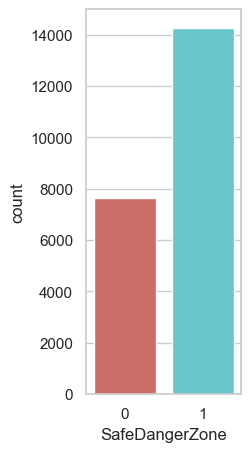

In [168]:
sns.countplot(x='SafeDangerZone', data=df, palette='hls')
plt.rcParams["figure.figsize"] = [2,5]
plt.show()

In [169]:
# Supprimer la colonne cible pour obtenir les features
X = df.drop(columns=['SafeDangerZone'])
# Sélectionner la colonne cible
y = df['SafeDangerZone']

In [170]:
sm = SMOTE(random_state=42, sampling_strategy=0.8)
X_sm, y_sm = sm.fit_resample(X, y)

In [171]:
# Reconstruire un DataFrame
df_sm = pd.DataFrame(X_sm, columns=X.columns)
df_sm['SafeDangerZone'] = y_sm

# Afficher un aperçu
df_sm.head()

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap,Deceleration,RelativeSpeed,TTC,SafeDistance,hard_brake,danger_accel_toward_leader,leader_stopped,no_reaction_to_stopped_leader,SafeDangerZone
0,0.0,10101,-100.00,-1.6,0.00,21,0.00,-1,-1.0,-1.0,0.0,1.00,999.0,0.000,False,False,False,False,0
1,0.1,10101,-99.97,-1.6,0.30,21,2.99,-1,-1.0,-1.0,0.0,1.30,999.0,0.090,False,False,False,False,0
2,0.2,10101,-99.91,-1.6,0.59,21,2.89,-1,-1.0,-1.0,0.0,1.59,999.0,0.177,False,False,False,False,0
3,0.3,10101,-99.83,-1.6,0.84,21,2.57,-1,-1.0,-1.0,0.0,1.84,999.0,0.252,False,False,False,False,0
4,0.4,10101,-99.72,-1.6,1.10,21,2.57,-1,-1.0,-1.0,0.0,2.10,999.0,0.330,False,False,False,False,0


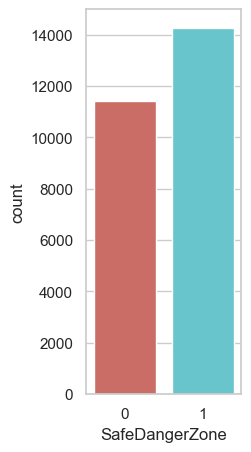

In [172]:
sns.countplot(x='SafeDangerZone', data=df_sm, palette='hls')
plt.rcParams["figure.figsize"] = [2,5]
plt.show()

In [173]:
X_features_input = df_sm.iloc[:,0:18] #features[rows, columms]
y_label_output = df_sm.iloc[:,18]
X_features_input.head(3)

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap,Deceleration,RelativeSpeed,TTC,SafeDistance,hard_brake,danger_accel_toward_leader,leader_stopped,no_reaction_to_stopped_leader
0,0.0,10101,-100.00,-1.6,0.00,21,0.00,-1,-1.0,-1.0,0.0,1.00,999.0,0.000,False,False,False,False
1,0.1,10101,-99.97,-1.6,0.30,21,2.99,-1,-1.0,-1.0,0.0,1.30,999.0,0.090,False,False,False,False
2,0.2,10101,-99.91,-1.6,0.59,21,2.89,-1,-1.0,-1.0,0.0,1.59,999.0,0.177,False,False,False,False


In [174]:
missing_data = df_sm.isnull()
missing_data

,Time,VehicleId,Pos_x,Pos_y,Speed,Lane,Acceleration,LeaderID,LeaderSpeed,LeaderGap,Deceleration,RelativeSpeed,TTC,SafeDistance,hard_brake,danger_accel_toward_leader,leader_stopped,no_reaction_to_stopped_leader,SafeDangerZone
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25684,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
25685,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
25686,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
25687,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [175]:
X_train, X_test, y_train, y_test = train_test_split(X_features_input, y_label_output, test_size=0.3, random_state=100)

In [176]:
X_train.shape

(17982, 18)

In [177]:
X_test.shape

(7707, 18)

In [178]:
# StandarScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [179]:
kernel_SVM = SVC(kernel='rbf')
kernel_SVM.fit(X_train_sc,y_train)
y_predictSVM_rbf = kernel_SVM.predict(X_test_sc)

In [180]:
print('Confusion matrix rbf SVM \n', confusion_matrix(y_test,y_predictSVM_rbf))
count_misclassified = (y_test != y_predictSVM_rbf).sum()
print('Misclassified samples: {}'.format(count_misclassified))
print('Accuracy rbf SVM:', accuracy_score(y_test,y_predictSVM_rbf)*100.0)
print('Precision rbf SVM: ', precision_score(y_test,y_predictSVM_rbf)*100.0)
print('Recall rbf SVM:', recall_score(y_test,y_predictSVM_rbf)*100.0)

Confusion matrix rbf SVM 
 [[3387   41]
 [   2 4277]]
Misclassified samples: 43
Accuracy rbf SVM: 99.44206565459972
Precision rbf SVM:  99.05048633626679
Recall rbf SVM: 99.95326010750175


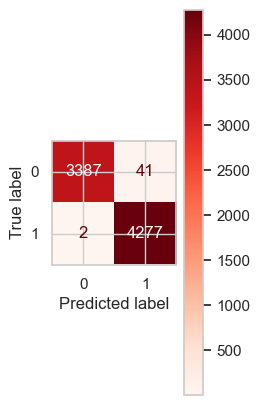

In [181]:
cm = confusion_matrix(y_test, y_predictSVM_rbf, labels=kernel_SVM.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=kernel_SVM.classes_)
disp.plot(cmap=plt.cm.Reds)
plt.show()